In [87]:
import numpy as np

def make_web(n,k,kmin=0):
    #den her funktion laver et helt random netværk af n sider, hvor hver side har mellem kmin og k links til andre sider.
    

    # Input: n og k er ikke-negative heltal
    # Output: web er en dictionary med n nøgler.
    # Værdien af hver nøgle er en mængde, der er en delmængde af nøglerne.
    
    assert(k < n), "k skal være mindre end n (da man ikke kan linke til sig selv)"
    assert(kmin <= k), "kmin skal være mindre end eller lig med k"
    keys = [i for i in range(n)]# laver en liste fra [0, 1, 2, ..., n-1]
    web = dict()
    for j in keys:
        #for hver hjemmeside finder vi hvor mange hjemmesider den skal linke til (numlinks) og derefter vælger vi hvilke hjemmesider den skal linke til (web[j])
        numlinks = np.random.randint(kmin,k) # generér et tilfældigt tal mellem kmin og k
        web[j] = set() # starter med en tom mængde for hver hjemmeside
        links = []
        for _ in range(numlinks): # nu vælger vi numlinks tilfældige hjemmesider at linke til
            link = np.random.choice(keys) # vælg en tilfældig hjemmeside fra keys
            if link != j: # sørg for at hjemmesiden ikke linker til sig selv
                links.append(int(link)) # tilføj den valgte hjemmeside til links-listen
        web[j] = set(links) # konverter links-listen til en mængde og tildel den til web[j]
    return web

In [88]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(web):
    
    # Input: netværk som dictionary
    # Output: Netværk visualiseret som graf

    G = nx.DiGraph()
    for node, links in web.items():
        G.add_node(node)
        for link in links:
            G.add_edge(node, link)

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', font_size=8, arrows=True)

    # INDSÆT KODE HER

    plt.show()

In [89]:
#opgave 9
def surf_step(web, startpage):
    
    # Input: Et netværk som dictionary og en start side
    # Output: Sandsynlighedsfordeling som dictionary for næste hjemmeside
    
    distribution=dict() # laver en tom dictionary til at gemme sandsynlighedsfordelingen

    for page, links in web.items(): # for hver hjemmeside og dens links i web-dictionaryen
        if links == set(): # hvis hjemmesiden ikke har nogen links, så skal den have en ligelig fordeling over alle sider
            distribution[page] = [1/len(web) for i in range(len(web))] # fordel sandsynligheden ligeligt over alle sider fx laver den [0, 0, 0, 0, 0] -> [1/5, 1/5, 1/5, 1/5, 1/5]
        else: # hvis hjemmesiden har links, så skal den fordele sandsynligheden ligeligt over de sider den linker til
            distribution[page] = [0 for i in range(len(web))] # starter med at lave [0, 0, 0, 0, 0] for hver hjemmeside
            for link in links:
                distribution[page][link] += 1/len(links) # her taget den fx [0, 1, 0, 1, 0] og laver den til [0, 1/2, 0, 1/2, 0] hvis der er 2 links

    
    return distribution[startpage] # returner sandsynlighedsfordelingen for den startside vi har valgt

In [90]:
#opgave 10
def random_surf(web, n):

    # Input: Et netværk som dictionary og antallet af skridt i random surf simuleringen
    # Output: PageRank-værdier for hver side som en dictionary
    ranking=dict()
    starts = [i for i in web.keys()] # en liste over alle hjemmesider
    start_page = np.random.choice(starts) # vælg en random hjemmeside at starte på
    for i in range(n):
        distribution = surf_step(web, start_page) # start med at find sandsynlighedsfordelingen for den startside vi har valgt
        indices = np.arange(len(distribution))
        start_page = np.random.choice(indices, p=distribution) # vælg en ny startside baseret på sandsynlighedsfordelingen
        if start_page not in ranking.keys(): # hver gang vi lander på en hjemmeside, så tæller vi det i ranking-dictionaryen
            ranking[int(start_page)] = 1
        else:
            ranking[int(start_page)] +=1
    for i in ranking.keys():
        ranking[i] = ranking[i]/n # til sidst dividerer vi hver tælling i ranking-dictionaryen med n for at få en sandsynlighedsfordeling over hvor ofte vi lander på hver hjemmeside
    
    # INDSÆT KODE HER

    return ranking

In [91]:
web = make_web(10, 6)

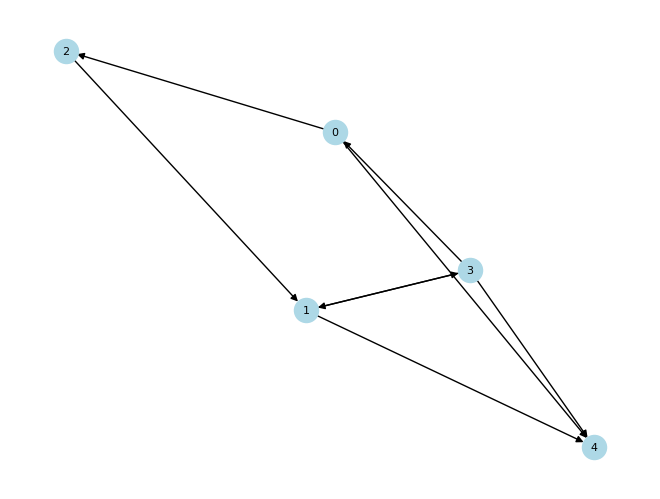

In [115]:
visualize_graph(W1)

# opgave 11

In [100]:
def surf_step_damp(web, start_page, d):
    
    # Input: Et netværk som dictionary, en start side og en dæmpningsfaktor
    # Output: Sandsynlighedsfordeling som dictionary for næste hjemmeside
    
    distribution=dict()

    distribution=dict() # laver en tom dictionary til at gemme sandsynlighedsfordelingen

    for page, links in web.items(): # for hver hjemmeside og dens links i web-dictionaryen
        if links == set(): # hvis hjemmesiden ikke har nogen links, så skal den have en ligelig fordeling over alle sider
            distribution[page] = [1/len(web) for i in range(len(web))] # fordel sandsynligheden ligeligt over alle sider fx laver den [0, 0, 0, 0, 0] -> [1/5, 1/5, 1/5, 1/5, 1/5]
        else: # hvis hjemmesiden har links, så skal den fordele sandsynligheden ligeligt over de sider den linker til
            distribution[page] = [0 for i in range(len(web))] # starter med at lave [0, 0, 0, 0, 0] for hver hjemmeside
            for link in links:
                distribution[page][link] += 1/len(links) # her taget den fx [0, 1, 0, 1, 0] og laver den til [0, 1/2, 0, 1/2, 0] hvis der er 2 links


    # INDSÆT KODE HER

    uniform = [1/len(web) for i in range(len(web))]
    sandsynlighed = [d, 1-d]
    indices = [1, 2]
    number = np.random.choice(indices, p=sandsynlighed)
    if number == 1:
        test = distribution[start_page]
    if number == 2:
        test = uniform
    return test

In [101]:
def random_surf_damp(web, n, d):

    # Input: Et netværk som dictionary, antallet af skridt i random surf simuleringen og en dæmpningsfaktor
    # Output: PageRank-værdier for hver side som en dictionary

        # Input: Et netværk som dictionary og antallet af skridt i random surf simuleringen
    # Output: PageRank-værdier for hver side som en dictionary
    ranking=dict()
    starts = [i for i in web.keys()] # en liste over alle hjemmesider
    start_page = np.random.choice(starts) # vælg en random hjemmeside at starte på
    for i in range(n):
        distribution = surf_step_damp(web, start_page, 0.85) # start med at find sandsynlighedsfordelingen for den startside vi har valgt
        indices = np.arange(len(distribution))
        start_page = np.random.choice(indices, p=distribution) # vælg en ny startside baseret på sandsynlighedsfordelingen
        if start_page not in ranking.keys(): # hver gang vi lander på en hjemmeside, så tæller vi det i ranking-dictionaryen
            ranking[int(start_page)] = 1
        else:
            ranking[int(start_page)] +=1
    for i in ranking.keys():
        ranking[i] = ranking[i]/n # til sidst dividerer vi hver tælling i ranking-dictionaryen med n for at få en sandsynlighedsfordeling over hvor ofte vi lander på hver hjemmeside
    



 
    # INDSÆT KODE HER

    return ranking

In [102]:
W2 = {
    0: {1},
    1: {2},
    2: {0},
    3: {4},
    4: {5},
    5: {3}}


W1 = {
    0: {2, 4},
    1: {3, 4},
    2: {1},
    3: {0, 1, 4},
    4: set()}

# opgave 13

In [113]:
for n in range(1000, 1010, 1):
    print(random_surf(W1, n))

{4: 0.32, 1: 0.239, 3: 0.183, 0: 0.14, 2: 0.118}
{2: 0.11588411588411589, 1: 0.25574425574425574, 3: 0.1978021978021978, 4: 0.3106893106893107, 0: 0.11988011988011989}
{4: 0.3013972055888224, 3: 0.1936127744510978, 0: 0.1217564870259481, 2: 0.124750499001996, 1: 0.25848303393213573}
{1: 0.24925224327018944, 3: 0.18943170488534397, 4: 0.32801595214356927, 0: 0.11764705882352941, 2: 0.1156530408773679}
{0: 0.11653386454183266, 4: 0.3047808764940239, 2: 0.1394422310756972, 1: 0.2559760956175299, 3: 0.18326693227091634}
{1: 0.24776119402985075, 3: 0.1761194029850746, 4: 0.31144278606965176, 0: 0.1373134328358209, 2: 0.12736318407960198}
{2: 0.12823061630218688, 1: 0.24353876739562624, 3: 0.18190854870775347, 0: 0.13916500994035785, 4: 0.3071570576540755}
{4: 0.2959285004965243, 3: 0.182720953326713, 1: 0.25521350546176763, 2: 0.13406156901688182, 0: 0.1320754716981132}
{0: 0.12400793650793651, 4: 0.34226190476190477, 3: 0.18452380952380953, 2: 0.10912698412698413, 1: 0.2400793650793651}
{4

In [114]:
for n in range(1000, 1010, 1):
    print(random_surf(W2, n))

{4: 0.334, 5: 0.333, 3: 0.333}
{5: 0.3336663336663337, 3: 0.3336663336663337, 4: 0.33266733266733267}
{3: 0.3333333333333333, 4: 0.3333333333333333, 5: 0.3333333333333333}
{5: 0.3339980059820538, 3: 0.33300099700897307, 4: 0.33300099700897307}
{2: 0.3336653386454183, 0: 0.3336653386454183, 1: 0.33266932270916333}
{3: 0.3333333333333333, 4: 0.3333333333333333, 5: 0.3333333333333333}
{4: 0.33399602385685884, 5: 0.33300198807157055, 3: 0.33300198807157055}
{3: 0.3336643495531281, 4: 0.3336643495531281, 5: 0.3326713008937438}
{2: 0.3333333333333333, 0: 0.3333333333333333, 1: 0.3333333333333333}
{4: 0.333994053518335, 5: 0.3330029732408325, 3: 0.3330029732408325}


In [111]:
for n in range(1000, 1010, 1):
    print(random_surf_damp(W1, n, 0.85))

{4: 0.309, 0: 0.132, 2: 0.131, 3: 0.178, 1: 0.25}
{3: 0.18181818181818182, 0: 0.14385614385614387, 4: 0.2937062937062937, 2: 0.13686313686313686, 1: 0.24375624375624375}
{3: 0.20658682634730538, 2: 0.14471057884231536, 1: 0.25848303393213573, 0: 0.12275449101796407, 4: 0.26746506986027946}
{3: 0.19441674975074777, 0: 0.13858424725822532, 4: 0.29810568295114653, 1: 0.2432701894317049, 2: 0.12562313060817548}
{4: 0.2968127490039841, 0: 0.11653386454183266, 1: 0.25796812749003983, 2: 0.1394422310756972, 3: 0.1892430278884462}
{2: 0.12736318407960198, 1: 0.25970149253731345, 4: 0.2855721393034826, 3: 0.19402985074626866, 0: 0.13333333333333333}
{4: 0.28926441351888665, 3: 0.1978131212723658, 2: 0.12524850894632206, 1: 0.24751491053677932, 0: 0.14015904572564614}
{1: 0.2701092353525323, 3: 0.18570009930486595, 0: 0.11618669314796425, 2: 0.13704071499503476, 4: 0.29096325719960275}
{0: 0.13988095238095238, 4: 0.3055555555555556, 2: 0.13194444444444445, 1: 0.24801587301587302, 3: 0.1746031746

In [112]:
for n in range(1000, 1010, 1):
    print(random_surf_damp(W2, n, 0.85))

{4: 0.173, 5: 0.176, 3: 0.165, 1: 0.157, 2: 0.163, 0: 0.166}
{2: 0.17682317682317683, 0: 0.18181818181818182, 5: 0.15384615384615385, 3: 0.15084915084915085, 4: 0.14885114885114886, 1: 0.1878121878121878}
{5: 0.16666666666666666, 3: 0.15768463073852296, 0: 0.17165668662674652, 1: 0.17465069860279442, 2: 0.16766467065868262, 4: 0.16167664670658682}
{4: 0.17547357926221335, 5: 0.16650049850448653, 3: 0.16849451645064806, 1: 0.1625124626121635, 2: 0.16051844466600199, 0: 0.16650049850448653}
{3: 0.18426294820717132, 4: 0.17131474103585656, 5: 0.18127490039840638, 0: 0.1603585657370518, 1: 0.14840637450199204, 2: 0.15438247011952191}
{5: 0.17213930348258707, 3: 0.17412935323383086, 4: 0.1771144278606965, 0: 0.16119402985074627, 1: 0.15522388059701492, 2: 0.16019900497512438}
{4: 0.15308151093439365, 2: 0.18389662027833, 0: 0.1908548707753479, 1: 0.18687872763419483, 5: 0.14314115308151093, 3: 0.14214711729622267}
{1: 0.1708043694141013, 2: 0.16881827209533268, 0: 0.17874875868917578, 4: 0.

# opgave 15

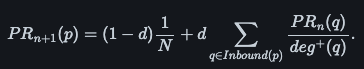

In [155]:
def rank_update(web, PageRanks, page, d):
        N = len(web)
        """
        Opdaterer værdien af PageRank for en side baseret på den rekursive formel
        Sider uden udgående links (sinks) behandles som om de linker til alle sider på nettet.

        Input: 
            web og PageRanks er dictionaries som i outputtet fra "make_web" og "random_surf",
            page er nøglen til den side, hvis rank vi ønsker at opdatere, og
            d er dampingfaktoren.
        Output: 
            PageRank opdateres i henhold til ovenstående formel,
            og denne funktion returnerer et float "increment", den (absolutte) forskel
            mellem den tidligere værdi og den opdaterede værdi af PR(p).
        """
        inbound_sum = 0
        for q, p in web.items():
            #print(q, p)
            if page in p:
                inbound_sum += PageRanks[q]/len(p)
            if p == set():
                 inbound_sum += PageRanks[q]/(len(web))
        
        increment = (1-d)*(1/N) + (d*(inbound_sum))

        return increment

In [162]:
def recursive_PageRank(web, stopvalue=0.0001, max_iterations=200, d=0.85):
    """
    Implementerer den rekursive version af PageRank-algoritmen ved først at oprette
    en PageRank på 1/N til alle sider (hvor N er det samlede antal sider)
    og derefter anvende "rank_update" gentagne gange, indtil en af de to stopbetingelser
    er opnået:
    stopbetingelse 1: den maksimale ændring fra trin n til trin (n+1) over alle PageRank
    er mindre end stopværdien,
    Stopbetingelse 2: antallet af iterationer har nået "max_iterations".

    Input: web er et dictionary som i outputtet af "make_web", d er dæmpningen,
    stopvalue er et positivt float, max_iterations er et positivt heltal.
    """
    PageRanks = dict()
    for i in range(len(web)):
        PageRanks[i] = 1/len(web)
    latest_increment = dict()
    for iteration in range(max_iterations):
        stop = 0 
        for page in web.keys():
            increment = rank_update(web, PageRanks, page, d)

            change = abs(increment - PageRanks[page])
            PageRanks[page] = increment
            print(change)
            if change < stopvalue:
                stop += 1
                print(stop)
        if stop == len(web.keys()):
            return PageRanks, iteration


    return PageRanks, iteration

In [163]:
recursive_PageRank(W1)

0.07933333333333334
0.09066666666666667
0.08471666666666669
0.012466666666666681
0.0919511111111111
0.01209946666666667
0.05990970000000004
0.020773962222222248
0.009829933611111119
0.007472808134259268
0.00405552523930558
0.013602342649583349
0.002993975609528965
0.004510618243248832
0.004065028518797809
0.001969063350449468
0.0005758159176501298
0.0015279067721366557
0.0004463330831943335
0.0014096460473737582
0.00036610086829194644
0.0016648216246080705
0.0003952326970776132
0.0009471890185119569
0.0013711521094477708
0.0005014660805178484
0.000837413873033821
0.0004462189428262042
0.000588996754645521
0.0009690022526818165
0.0003316127967721294
0.0007108988981744113
0.0003056658215840613
0.0004668624146799971
0.0007400755374675216
0.0002580905255288035
0.000517906473875257
0.00023550131471924973
0.0003459230927664869
0.0005536231090667032
0.00019212747149185971
0.00039230358900319007
0.00017577010392536008
0.0002608449538677171
0.00041640519951424704
0.00014469495417993028
0.000294

({0: 0.1327714381200655,
  1: 0.24880659980250253,
  2: 0.1365540842634364,
  3: 0.18586902797847216,
  4: 0.29495978044006715},
 13)

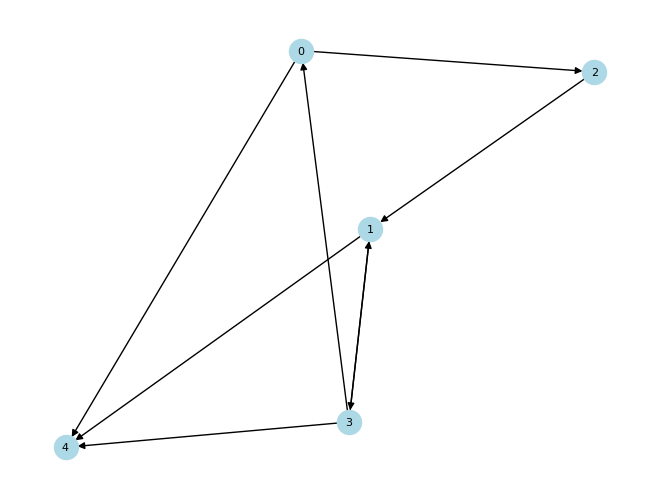

In [128]:
visualize_graph(W1)